In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [166]:
tg = pd.read_csv('API_Date_Final.csv')
site = pd.read_csv('Parsing_final (2).csv')

In [167]:
tg.head(3)

,id_post,date,content,views,reactions_count,reactions_detail,forwards,has_media,media_type,post_url,date_only
0,120032,2025-06-04 04:17:36+00:00,ФНС задумалась об усилении контроля за дроблен...,173042.0,582,"👎:203, ❤:161, 👍:94, 🤔:76, 🤡:34, 😱:7, 🤣:7",311.0,0,no_media,https://t.me/rbc_news/120032,2025-06-04
1,120033,2025-06-04 05:03:39+00:00,Федеральное казначейство потребовало у судоход...,153367.0,551,"❤:228, 🤔:113, 🤡:91, 👍:40, 😱:27, 🤣:25, 🤯:10, 🤬:...",70.0,0,no_media,https://t.me/rbc_news/120033,2025-06-04
2,120035,2025-06-04 06:07:35+00:00,В 2025 году комиссии на трансграничные расчеты...,144466.0,304,"❤:157, 👍:54, 🤔:45, 🤡:28, 🤣:9, 👎:5, 👏:3, 🥱:3",71.0,0,no_media,https://t.me/rbc_news/120035,2025-06-04


In [168]:
site.head(3)


,title,content,link,date,source_type,source_name,day,hour
0,Военная операция на Украине. Онлайн,UNKNOWN,https://tass.ru/armiya-i-opk/27004755,2026-04-06 00:00:00+03:00,website,tass.ru,2026-04-06,0
1,Военная операция США и Израиля в Иране. Онлайн,Любая наземная операция обречена на полный про...,https://tass.ru/mezhdunarodnaya-panorama/27004757,2026-04-06 00:00:01+03:00,website,tass.ru,2026-04-06,0
2,Военная операция США и Израиля в Иране. Онлайн,UNKNOWN,https://tass.ru/mezhdunarodnaya-panorama/27004757,2026-04-06 00:00:01+03:00,website,tass.ru,2026-04-06,0


In [169]:
tg.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_post           349 non-null    int64  
 1   date              349 non-null    object 
 2   content           349 non-null    object 
 3   views             349 non-null    float64
 4   reactions_count   349 non-null    int64  
 5   reactions_detail  349 non-null    object 
 6   forwards          349 non-null    float64
 7   has_media         349 non-null    int64  
 8   media_type        349 non-null    object 
 9   post_url          349 non-null    object 
 10  date_only         349 non-null    object 
dtypes: float64(2), int64(3), object(6)
memory usage: 30.1+ KB


In [170]:
site.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2502 entries, 0 to 2501
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        2502 non-null   object
 1   content      2502 non-null   object
 2   link         2502 non-null   object
 3   date         2502 non-null   object
 4   source_type  2502 non-null   object
 5   source_name  2502 non-null   object
 6   day          2502 non-null   object
 7   hour         2502 non-null   int64 
dtypes: int64(1), object(7)
memory usage: 156.5+ KB


In [171]:
topics = {
    'Политика':   ['трамп', 'президент', 'путин', 'министр', 'санкц', 'выборы', 'правительств'],
    'Война':      ['украин', 'атак', 'удар', 'обстрел', 'войск', 'иран', 'израил', 'ракет'],
    'Экономика':  ['рубл', 'доллар', 'инфляц', 'ставк', 'бюджет', 'банк', 'ввп'],
    'Бизнес':     ['компани', 'рынк', 'акци', 'миллиард', 'бизнес', 'сделк'],
    'Технологии': ['цифров', 'технолог', 'интернет', 'платформ', 'искусственн'],
}

In [172]:
def get_topic(text):
    if pd.isna(text):
        return 'Другое'
    t = text.lower()
    for topic, kws in topics.items():
        if any(k in t for k in kws):
            return topic
    return 'Другое'

In [173]:
tg['topic'] = tg['content'].apply(get_topic)
site['topic'] = site['title'].apply(get_topic)

In [174]:
print('Темы в Тг:')
tg['topic'].value_counts()

Темы в Тг:


,count
topic,
Политика,138
Другое,81
Война,75
Экономика,26
Бизнес,23
Технологии,6


In [175]:
print('Темы на сайте:')
site['topic'].value_counts()

Темы на сайте:


,count
topic,
Другое,1718
Война,539
Политика,128
Экономика,62
Бизнес,40
Технологии,15


Распределение частоты появления темы на сайте

In [176]:
site_topic = site['topic'].value_counts()

Text(0, 0.5, 'Кол-во статей')

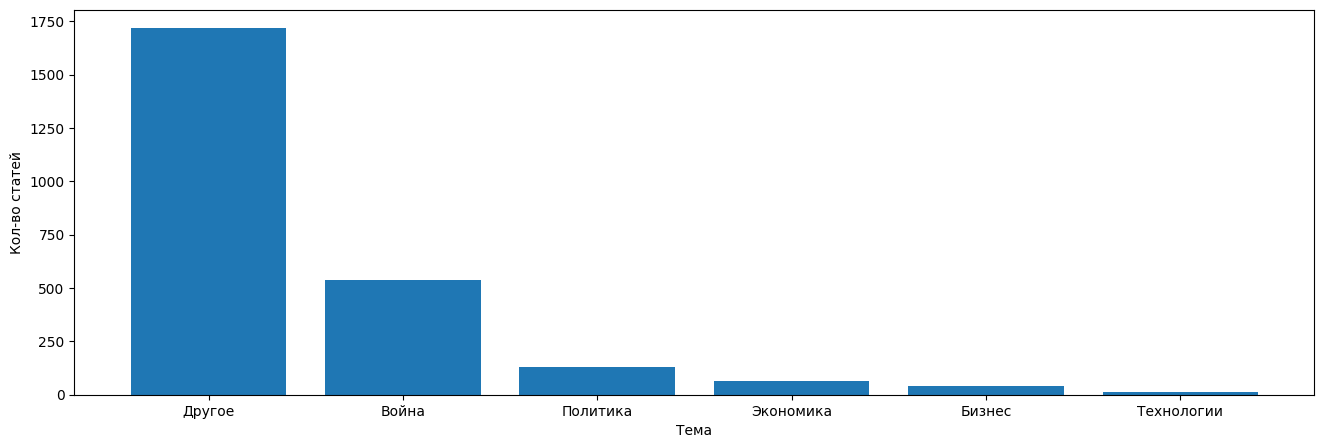

In [177]:
plt.figure(figsize=(16, 5))
plt.bar(site_topic.index, site_topic.values)
plt.xlabel('Тема')
plt.ylabel('Кол-во статей')


Количество публикаций на сайте по часам

In [178]:
site['dt'] = pd.to_datetime(site['date'])
site['hour'] = site['dt'].dt.hour

In [179]:
site_hours = site.groupby('hour').size()

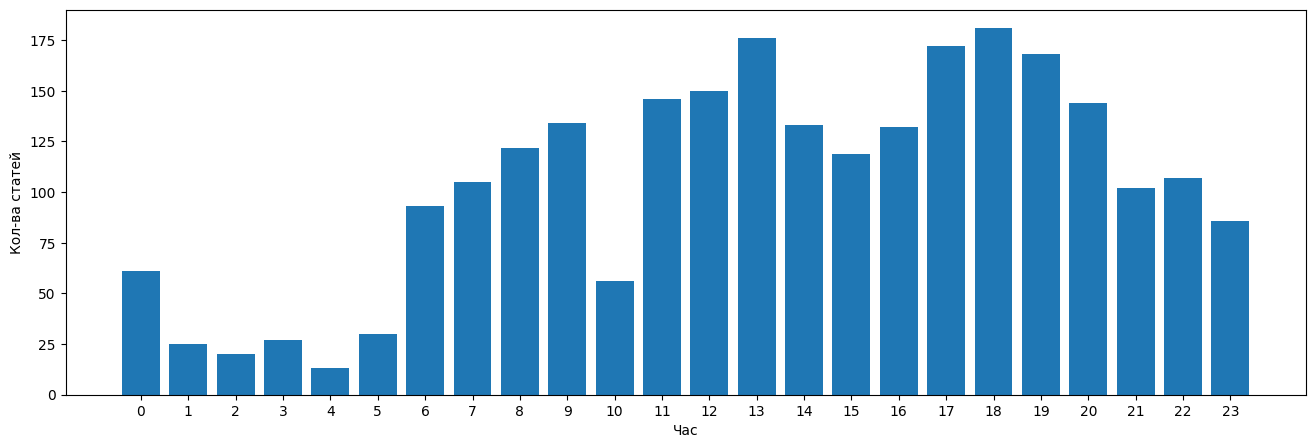

In [180]:
plt.figure(figsize=(16, 5))
plt.bar(site_hours.index, site_hours.values)
plt.xlabel('Час')
plt.ylabel('Кол-ва статей')
plt.xticks(range(0, 24))
plt.show()

Количество статей по теме и часу публикации

In [181]:
site_pivot = site.groupby(['hour', 'topic']).size().unstack(fill_value=0)

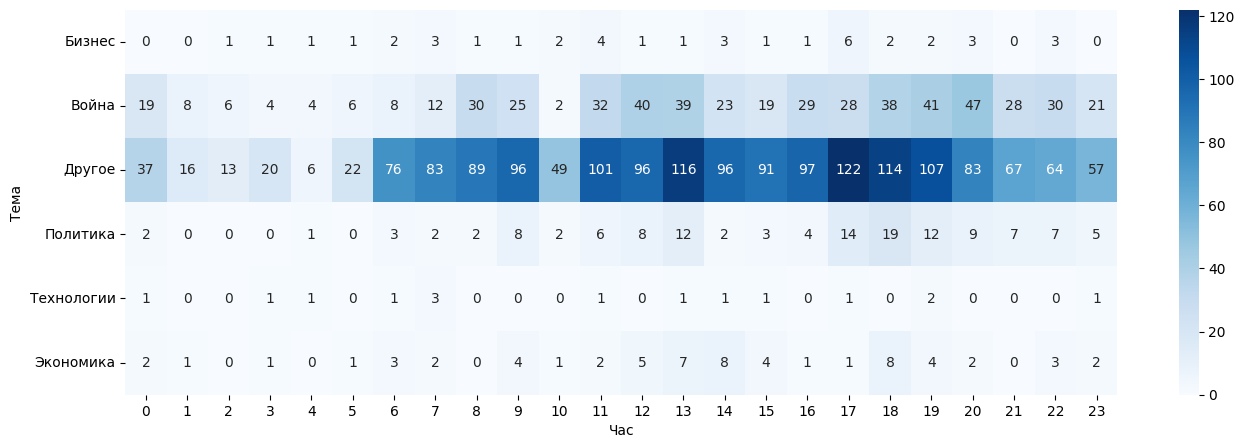

In [182]:
plt.figure(figsize=(16, 5))
sns.heatmap(site_pivot.T, cmap='Blues', annot=True, fmt='.0f')
plt.xlabel('Час')
plt.ylabel('Тема')
plt.show()

Средние просмотры по теме

In [183]:
tg_topic_views = tg.groupby('topic')['views'].mean().sort_values(ascending=False).round(0)

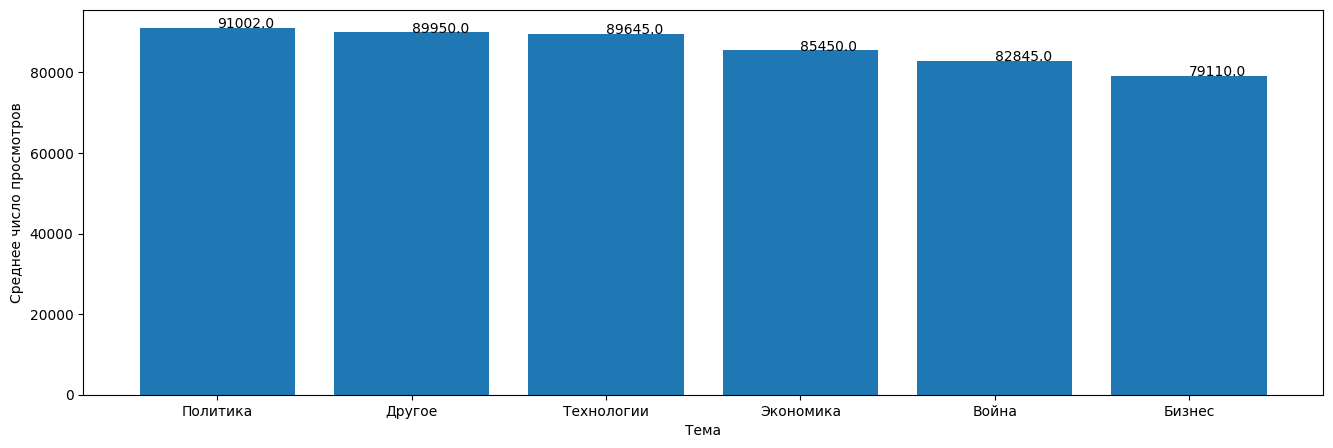

In [184]:
plt.figure(figsize=(16, 5))
plt.bar(tg_topic_views.index, tg_topic_views.values)
plt.xlabel('Тема')
plt.ylabel('Среднее число просмотров')
for i, j in enumerate(tg_topic_views.values):
    plt.text(i, j, j)
plt.show()

Средние реакции по теме

In [185]:
tg_topic_react = tg.groupby('topic')['reactions_count'].mean().sort_values(ascending=False).round(2)

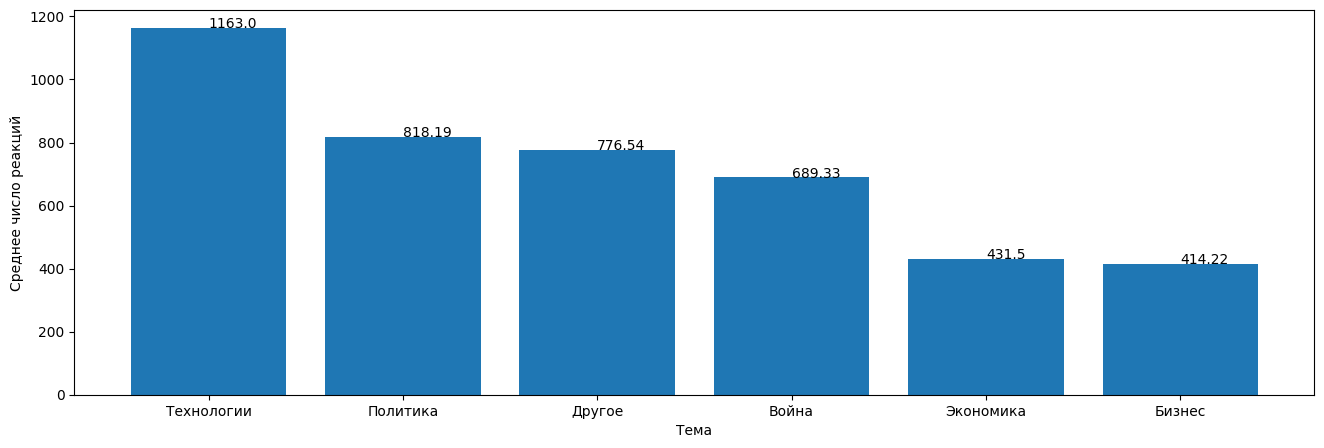

In [186]:
plt.figure(figsize=(16, 5))
plt.bar(tg_topic_react.index, tg_topic_react.values)
plt.xlabel('Тема')
plt.ylabel('Среднее число реакций')
for i, j in enumerate(tg_topic_react.values):
    plt.text(i, j, j)
plt.show()

Просмотры по часам


In [187]:
tg['dt'] = pd.to_datetime(tg['date'])
tg['hour'] = tg['dt'].dt.hour

In [188]:
tg_hour_views = tg.groupby('hour')['views'].mean().round(0)

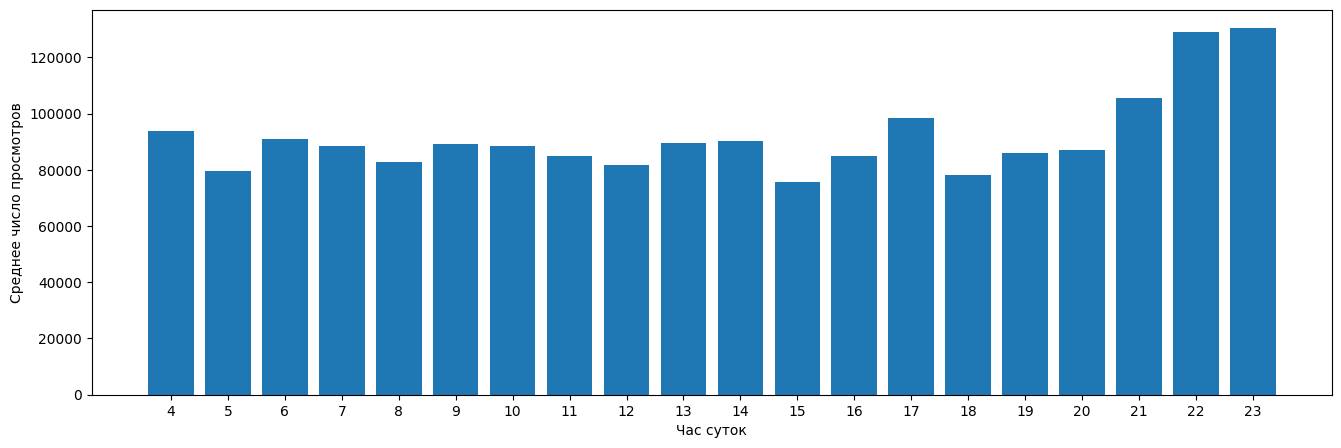

In [189]:
plt.figure(figsize=(16, 5))
plt.bar(tg_hour_views.index, tg_hour_views.values)
plt.xlabel('Час суток')
plt.ylabel('Среднее число просмотров')
plt.xticks(sorted(tg_hour_views.index))
plt.show()

Реакции по часу публикации

In [190]:
tg_hour_react = tg.groupby('hour')['reactions_count'].mean().round(1)

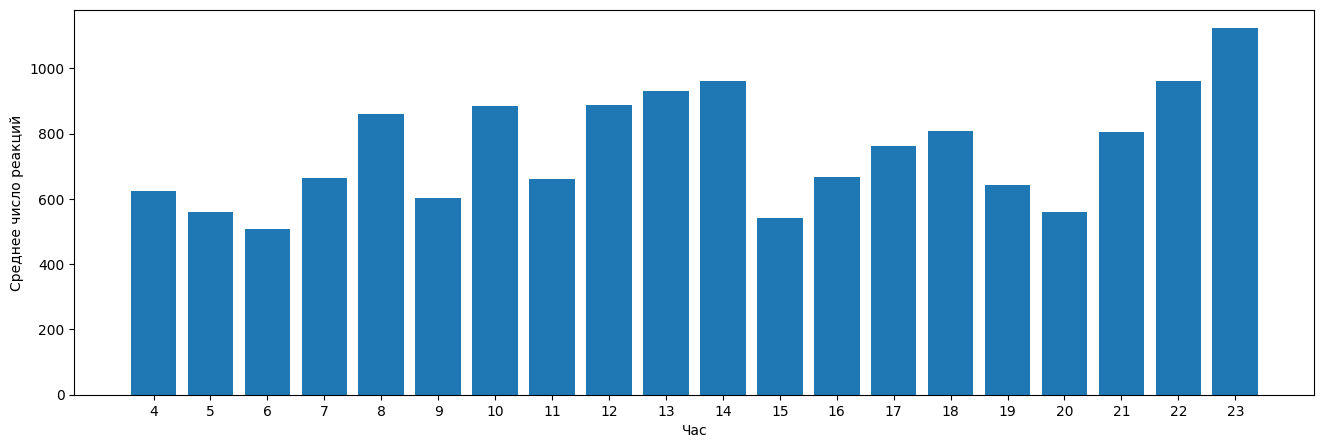

In [191]:
plt.figure(figsize=(16, 5))
plt.bar(tg_hour_react.index, tg_hour_react.values)
plt.xlabel('Час')
plt.ylabel('Среднее число реакций')
plt.xticks(sorted(tg_hour_react.index))
plt.show()

Просмотры по теме и часу

In [192]:
tg_pivot = tg.groupby(['hour', 'topic'])['views'].mean().round(0).unstack(fill_value=0)

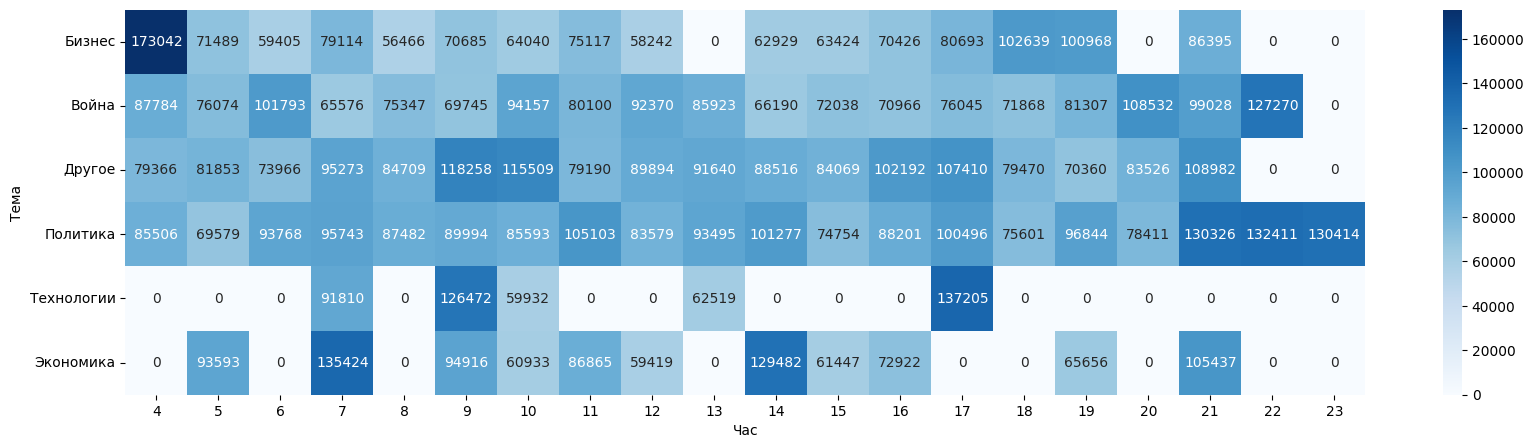

In [193]:
plt.figure(figsize=(20, 5))
sns.heatmap(tg_pivot.T, cmap='Blues', annot=True, fmt='.0f')
plt.xlabel('Час')
plt.ylabel('Тема')
plt.show()

Число просмотров в зависимости от длины текста

In [194]:
tg['text_len'] = tg['content'].str.len()
bins_text  = [0, 300, 500, 700, 1000, 5000]
labels_text = ['< 300', '300–500', '500–700', '700–1000', '> 1000']
tg['text_bin'] = pd.cut(tg['text_len'], bins=bins_text, labels=labels_text)

In [195]:
text_views = tg.groupby('text_bin', observed=True)['views'].mean().round(0)

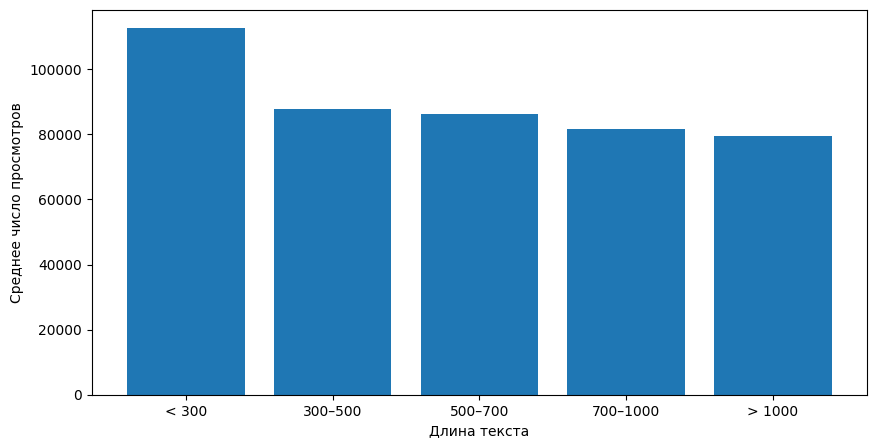

In [196]:
plt.figure(figsize=(10, 5))
plt.bar(text_views.index, text_views.values)
plt.xlabel('Длина текста')
plt.ylabel('Среднее число просмотров')
plt.show()

Коррекляция показателей телеграмма



In [197]:
corr_cols = ['views', 'reactions_count', 'forwards', 'text_len', 'has_media']
corr_labels = ['Просмотры', 'Реакции', 'Репосты', 'Длина текста', 'Есть медиа']

In [198]:
corr_matrix = tg[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

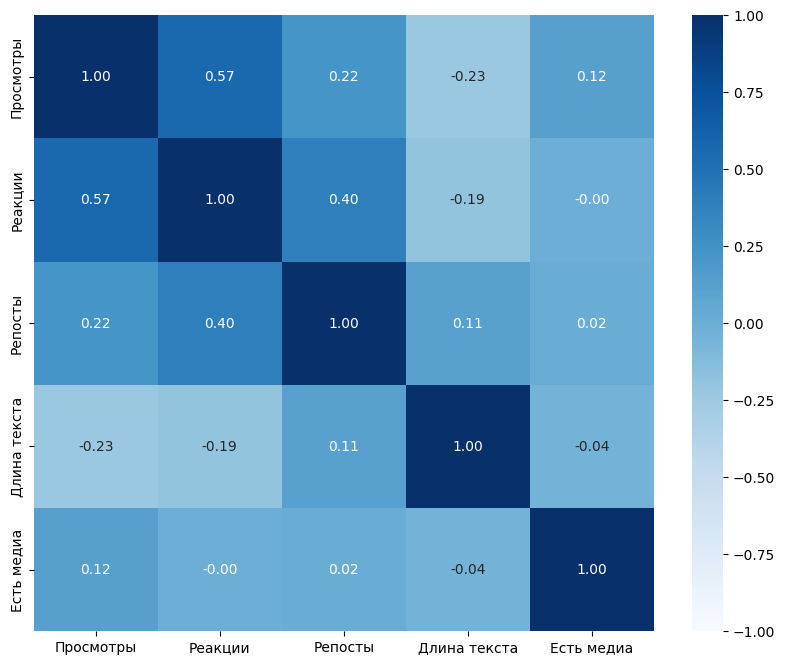

In [199]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1)
plt.show()